<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/Calculus/w1/sympy_module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### sympy는 파이썬에서 사용 가능한 대수(algebra) 계산 라이브러리로, 기호 연산과 수학적 공식 표현을 지원
- 기호 연산
- 방정식 풀기
- 미분과 적분
- 방정식 그래프 그리기

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
from sympy import symbols
x, y = symbols('x y')
expr = x + 2*y
expr

x + 2*y

In [3]:
from sympy import Eq, solve
eq = Eq(x**2 + 2*x + 1, 0)
eq
sol = solve(eq, x)
sol

Eq(x**2 + 2*x + 1, 0)

[-1]

In [4]:
from sympy import diff, integrate
expr = x**2 + 3*x + 2
derivative = diff(expr, x)
integral = integrate(expr, x)

expr
print()
derivative
integral
print()
derivative.subs(x, 1)
integral.subs(x, 1)

x**2 + 3*x + 2

2*x + 3

x**3/3 + 3*x**2/2 + 2*x

5

23/6

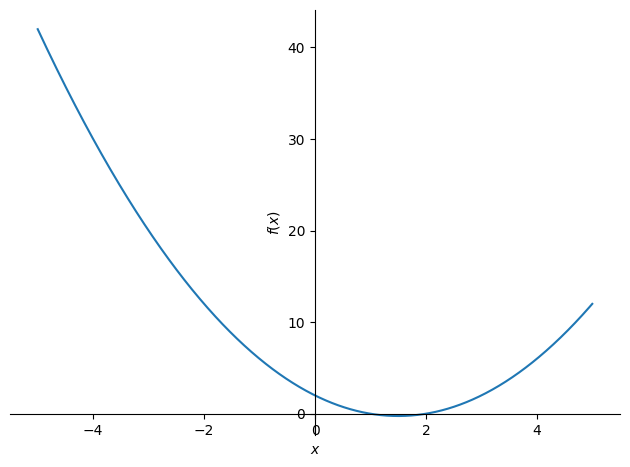

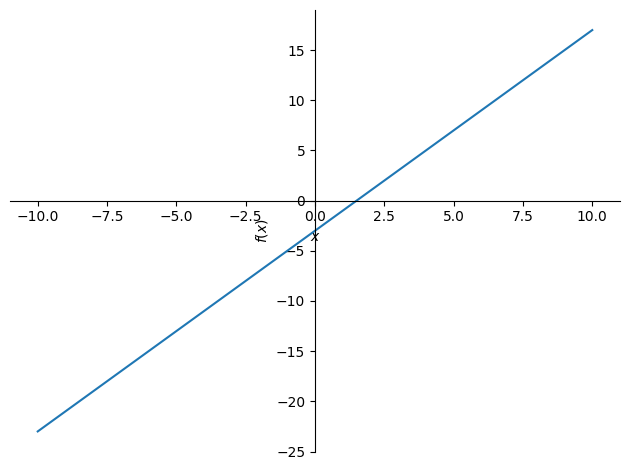

In [5]:
from sympy.plotting import plot
expr = x**2 - 3*x + 2
plot(expr, (x, -5, 5)); plot(diff(expr, x))

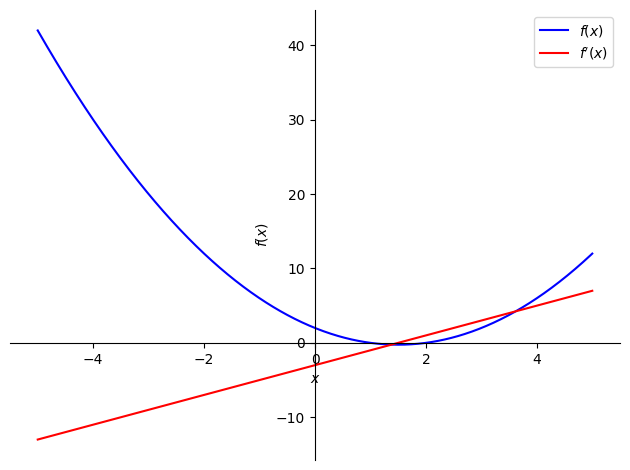

In [6]:
from sympy import symbols, diff, plot

x = symbols('x')
expr = x**2 - 3*x + 2
d_expr = diff(expr, x)

# 여러 수식을 한 번에 입력 (범위는 공유됨)
p = plot(expr, d_expr, (x, -5, 5), show=False, legend=True)

# 그래프별 색상 및 이름 설정
p[0].line_color = 'blue'
p[0].label = '$f(x)$'

p[1].line_color = 'red'
p[1].label = "$f'(x)$"

p.show()

핵심 개념 이해

- 미분 (Differentiation): 위치를 시간에 대해 미분하면 속도가 되고, 속도를 미분하면 가속도가 됩니다. (순간적인 변화율)

- 적분 (Integration): 가속도를 시간에 대해 적분하면 속도가 되고, 속도를 적분하면 **변화된 거리(위치)** 가 됩니다. (누적된 총량)

In [7]:
import sympy as sp

# 1. 변수 및 함수 선언
t = sp.symbols('t')
s = t**3 - 6*t**2 + 9*t  # 위치 함수

# 2. 미분: 위치 -> 속도 -> 가속도
v = sp.diff(s, t)  # 속도 함수
a = sp.diff(v, t)  # 가속도 함수

print(f"위치 함수: s(t) = {s}")
print(f"속도 함수: v(t) = {v}")
print(f"가속도 함수: a(t) = {a}")

# 3. 특정 시간(t=2)에서의 값 계산
t_val = 2
print(f"\n시간 t={t_val}일 때:")
print(f"위치: {s.subs(t, t_val)}")
print(f"속도: {v.subs(t, t_val)}")

위치 함수: s(t) = t**3 - 6*t**2 + 9*t
속도 함수: v(t) = 3*t**2 - 12*t + 9
가속도 함수: a(t) = 6*t - 12

시간 t=2일 때:
위치: 2
속도: -3


'\nSymPy의 추상적인 수식을 NumPy가 이해할 수 있는 고속 계산 함수로 바꿉니다.\n컴퓨터는 그래프를 그릴 때 수천 개의 점을 찍어야 하는데, 기호 수식 상태로는 점을 찍기 어렵기 때문에\n이 과정을 통해 "입력값을 넣으면 결과값이 나오는 실제 함수"로 변환\n'

Text(0.5, 1.0, 'Position: $s(t)$')

Text(0.5, 0, 'Time (s)')

Text(0.5, 1.0, 'Velocity: $v(t)$ (Integral of $a$)')

Text(0.5, 0, 'Time (s)')

Text(0.5, 1.0, 'Acceleration: $a(t)$')

Text(0.5, 0, 'Time (s)')

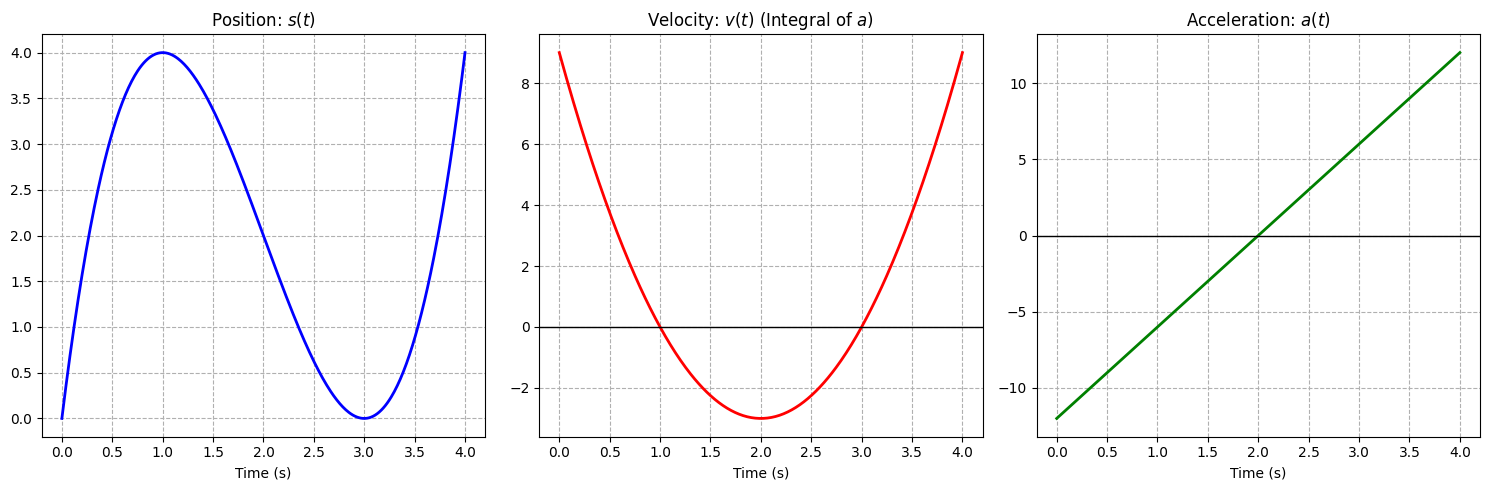

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# 1. 기호 계산 (SymPy)
t_sym = sp.symbols('t')
s_sym = t_sym**3 - 6*t_sym**2 + 9*t_sym
v_sym = sp.diff(s_sym, t_sym)
a_sym = sp.diff(v_sym, t_sym)

# 2. 수식을 수치 함수로 변환
'''
SymPy의 추상적인 수식을 NumPy가 이해할 수 있는 고속 계산 함수로 바꿉니다.
컴퓨터는 그래프를 그릴 때 수천 개의 점을 찍어야 하는데, 기호 수식 상태로는 점을 찍기 어렵기 때문에
이 과정을 통해 "입력값을 넣으면 결과값이 나오는 실제 함수"로 변환
'''
s_func = sp.lambdify(t_sym, s_sym, 'numpy')
v_func = sp.lambdify(t_sym, v_sym, 'numpy')
a_func = sp.lambdify(t_sym, a_sym, 'numpy')

# 3. 데이터 준비 (0초 ~ 4초)
t_vals = np.linspace(0, 4, 400)
s_vals = s_func(t_vals)
v_vals = v_func(t_vals)
a_vals = a_func(t_vals)

# 4. 그래프 그리기 (1행 3열 설정)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (1) 위치 그래프: s(t)
axes[0].plot(t_vals, s_vals, color='blue', lw=2)
axes[0].set_title('Position: $s(t)$')
axes[0].set_xlabel('Time (s)')
axes[0].grid(True, linestyle='--')

# (2) 속도 그래프: v(t) = s'(t)
axes[1].plot(t_vals, v_vals, color='red', lw=2)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Velocity: $v(t)$ (Integral of $a$)')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True, linestyle='--')

# (3) 가속도 그래프: a(t) = v'(t)
axes[2].plot(t_vals, a_vals, color='green', lw=2)
axes[2].axhline(0, color='black', lw=1)
axes[2].set_title('Acceleration: $a(t)$')
axes[2].set_xlabel('Time (s)')
axes[2].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Position: $s(t) = 6 t^{2} + 9 t + 2$')

Text(0.5, 0, 'Time (s)')

Text(0.5, 1.0, 'Velocity: $v(t) = 12 t + 9$')

Text(0.5, 0, 'Time (s)')

(0.0, 20.0)

Text(0.5, 1.0, 'Acceleration: $a(t) = 12$')

Text(0.5, 0, 'Time (s)')

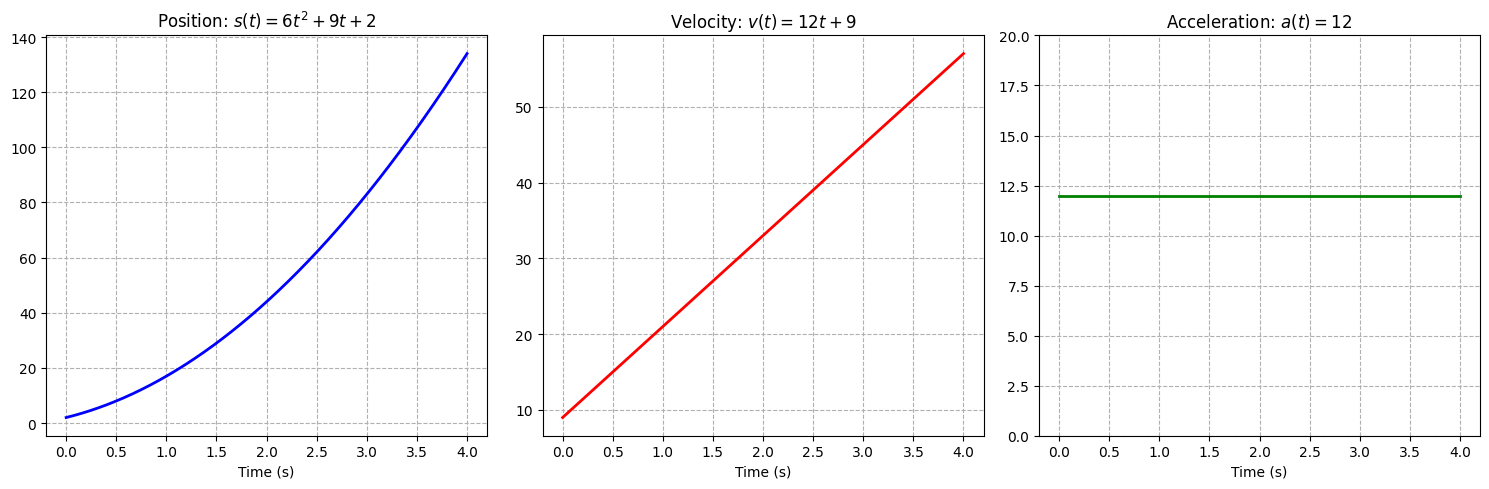

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# 1. 기호 계산 (SymPy)
t = sp.symbols('t')
s_sym = 6*t**2 + 9*t + 2  # 수정된 위치 함수
v_sym = sp.diff(s_sym, t)    # 속도: 12t + 9
a_sym = sp.diff(v_sym, t)    # 가속도: 12 (상수)

# 2. 수치 함수로 변환 (Lambdify)
s_func = sp.lambdify(t, s_sym, 'numpy')
v_func = sp.lambdify(t, v_sym, 'numpy')
# 가속도가 상수인 경우 numpy 배열 연산을 위해 변환 방식을 맞춤
a_func = lambda t_arr: np.full_like(t_arr, float(a_sym))

# 3. 데이터 준비 (0초 ~ 4초)
t_vals = np.linspace(0, 4, 400)
s_vals = s_func(t_vals)
v_vals = v_func(t_vals)
a_vals = a_func(t_vals)

# 4. 그래프 그리기
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (1) 위치 그래프: s(t) - 포물선 형태
axes[0].plot(t_vals, s_vals, color='blue', lw=2)
axes[0].set_title(f'Position: $s(t) = {sp.latex(s_sym)}$')
axes[0].set_xlabel('Time (s)')
axes[0].grid(True, linestyle='--')

# (2) 속도 그래프: v(t) - 직선 형태
axes[1].plot(t_vals, v_vals, color='red', lw=2)
axes[1].set_title(f'Velocity: $v(t) = {sp.latex(v_sym)}$')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True, linestyle='--')

# (3) 가속도 그래프: a(t) - 수평선 형태
axes[2].plot(t_vals, a_vals, color='green', lw=2)
axes[2].set_ylim(0, 20) # 변화를 잘 보기 위해 범위를 고정
axes[2].set_title(f'Acceleration: $a(t) = {sp.latex(a_sym)}$')
axes[2].set_xlabel('Time (s)')
axes[2].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

## 실전문제

어떤 자동차의 위치 함수가 $s(t) = -t^2 + 8t + 10$ (단위: $m$, $s$)라고 합시다. 이 자동차가 잠시 멈추는 시간($t$)과 그때의 위치를 구하세요.

In [10]:
# 문제 풀이 코드
s_prob1 = -t**2 + 8*t + 10
v_prob1 = sp.diff(s_prob1, t)

# v(t) = 0 인 t 찾기
stop_time = sp.solve(v_prob1, t)
print(f"자동차 멈추는 시간: {stop_time[0]}초")

# 그때의 위치
stop_pos = s_prob1.subs(t, stop_time[0])
print(f"멈췄을 때의 위치: {stop_pos}m")

자동차 멈추는 시간: 4초
멈췄을 때의 위치: 26m


Text(0.5, 1.0, 'Position: $s(t) = - t^{2} + 8 t + 10$')

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Position (m)')

Text(0.5, 1.0, 'Velocity: $v(t) = 8 - 2 t$')

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Velocity (m/s)')

(-5.0, 5.0)

Text(0.5, 1.0, 'Acceleration: $a(t) = -2$')

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Accel (m/s²)')

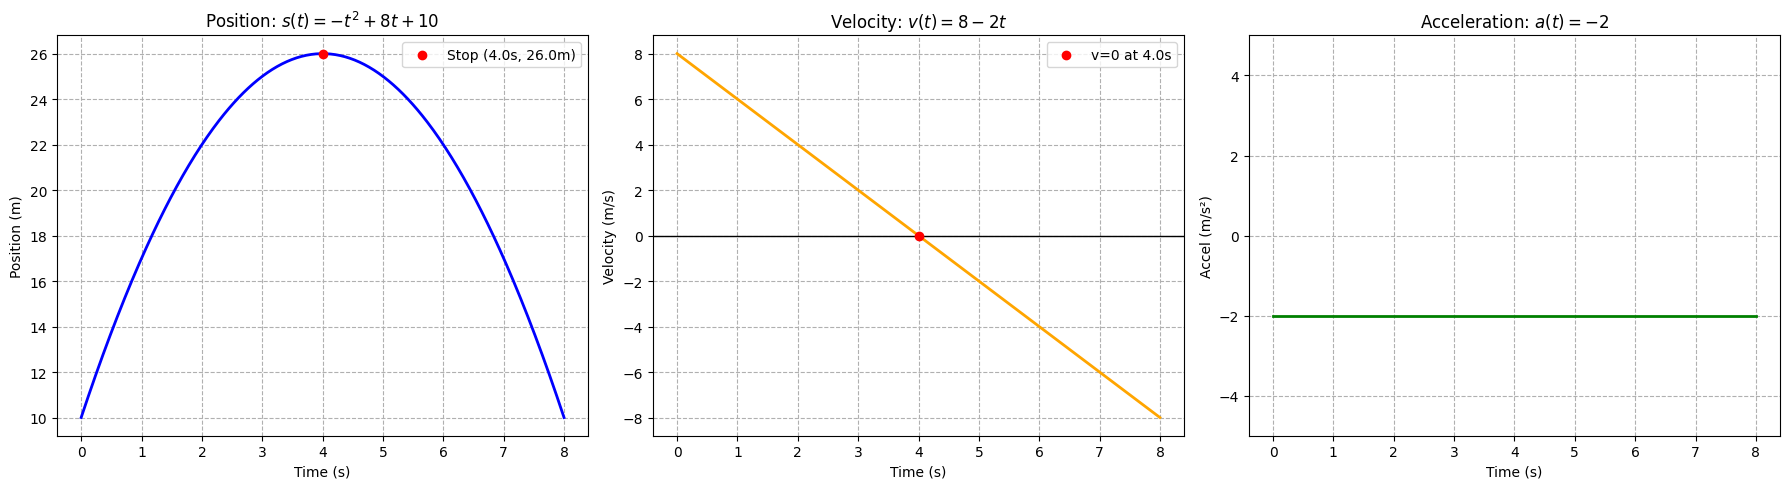

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# 1. 기호 계산 (SymPy)
t = sp.symbols('t')
s_sym = -t**2 + 8*t + 10  # 위치 함수
v_sym = sp.diff(s_sym, t)   # 속도 함수: -2t + 8
a_sym = sp.diff(v_sym, t)   # 가속도 함수: -2 (상수)

# 자동차가 멈추는 시간 계산 (v=0)
stop_time = float(sp.solve(v_sym, t)[0])
stop_pos = float(s_sym.subs(t, stop_time))

# 2. 수치 함수로 변환
s_func = sp.lambdify(t, s_sym, 'numpy')
v_func = sp.lambdify(t, v_sym, 'numpy')
a_func = lambda t_arr: np.full_like(t_arr, float(a_sym))

# 3. 데이터 준비 (0초 ~ stop_time의 2배인 8초까지)
t_vals = np.linspace(0, 8, 400)
s_vals = s_func(t_vals)
v_vals = v_func(t_vals)
a_vals = a_func(t_vals)

# 4. 그래프 그리기
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) 위치 그래프
axes[0].plot(t_vals, s_vals, color='blue', lw=2)
axes[0].scatter(stop_time, stop_pos, color='red', zorder=5, label=f'Stop ({stop_time}s, {stop_pos}m)')
axes[0].set_title(f'Position: $s(t) = {sp.latex(s_sym)}$')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Position (m)')
axes[0].legend()
axes[0].grid(True, linestyle='--')

# (2) 속도 그래프
axes[1].plot(t_vals, v_vals, color='orange', lw=2)
axes[1].axhline(0, color='black', lw=1)
axes[1].scatter(stop_time, 0, color='red', zorder=5, label=f'v=0 at {stop_time}s')
axes[1].set_title(f'Velocity: $v(t) = {sp.latex(v_sym)}$')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Velocity (m/s)')
axes[1].legend()
axes[1].grid(True, linestyle='--')

# (3) 가속도 그래프
axes[2].plot(t_vals, a_vals, color='green', lw=2)
axes[2].set_ylim(-5, 5)
axes[2].set_title(f'Acceleration: $a(t) = {sp.latex(a_sym)}$')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Accel (m/s²)')
axes[2].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

자유 낙하하는 물체의 속도 함수가 $v(t) = 9.8t$입니다. $t=0$부터 $t=5$초까지 이 물체가 낙하한 총 거리를 구하세요

In [12]:
# 문제 풀이 코드
v_prob2 = 9.8 * t

# 0초부터 5초까지 정적분
distance = sp.integrate(v_prob2, (t, 0, 5))
print(f"5초 동안 낙하한 총 거리: {distance}m")

5초 동안 낙하한 총 거리: 122.500000000000m


Text(0.5, 1.0, 'Velocity: Area is Distance')

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Velocity (m/s)')

Text(0, 10, 'Dist: 122.50000000000001m')

Text(0.5, 1.0, 'Position: Result of Integration')

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Distance (m)')

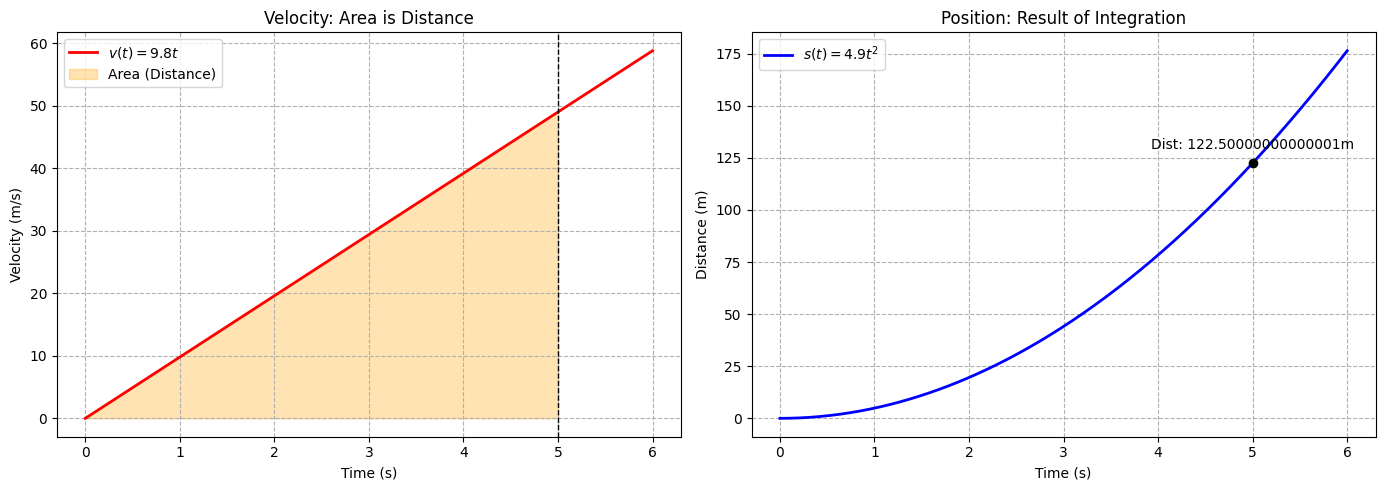

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# 1. 기호 및 수식 정의
t = sp.symbols('t')
v_sym = 9.8 * t
s_sym = sp.integrate(v_sym, t)  # 부정적분: 4.9*t^2

# 2. 수치 함수로 변환
v_func = sp.lambdify(t, v_sym, 'numpy')
s_func = sp.lambdify(t, s_sym, 'numpy')

# 3. 데이터 준비
t_vals = np.linspace(0, 6, 400)
v_vals = v_func(t_vals)
s_vals = s_func(t_vals)

# 적분 구간 설정 (0초 ~ 5초)
t_fill = np.linspace(0, 5, 100)
v_fill = v_func(t_fill)

# 4. 그래프 그리기 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) 속도 그래프와 적분 영역 (v-t 그래프)
axes[0].plot(t_vals, v_vals, color='red', lw=2, label='$v(t) = 9.8t$')
axes[0].fill_between(t_fill, v_fill, color='orange', alpha=0.3, label='Area (Distance)')
axes[0].axvline(5, color='black', linestyle='--', lw=1)
axes[0].set_title('Velocity: Area is Distance')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Velocity (m/s)')
axes[0].legend()
axes[0].grid(True, linestyle='--')

# (2) 위치 그래프 (s-t 그래프)
axes[1].plot(t_vals, s_vals, color='blue', lw=2, label='$s(t) = 4.9t^2$')
axes[1].scatter(5, s_func(5), color='black', zorder=5)
axes[1].annotate(f'Dist: {s_func(5)}m', (5, s_func(5)), textcoords="offset points", xytext=(0,10), ha='center')
axes[1].set_title('Position: Result of Integration')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Distance (m)')
axes[1].legend()
axes[1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()